In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [9]:
data = pd.read_excel(r"C:\Users\mohammed hamza\Downloads\Salary (1).xlsx")
data

,Experience,Salary
0,1.0,34000
1,1.5,35900
2,1.6,34000
3,2.0,42579
4,1.7,33990
5,1.5,34000
6,2.2,43000
7,2.7,42500
8,1.1,30000
9,2.9,45900


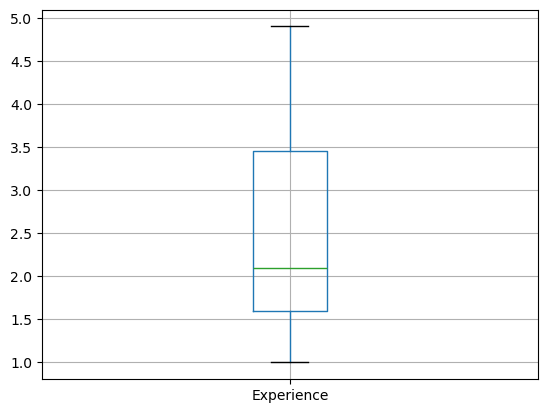

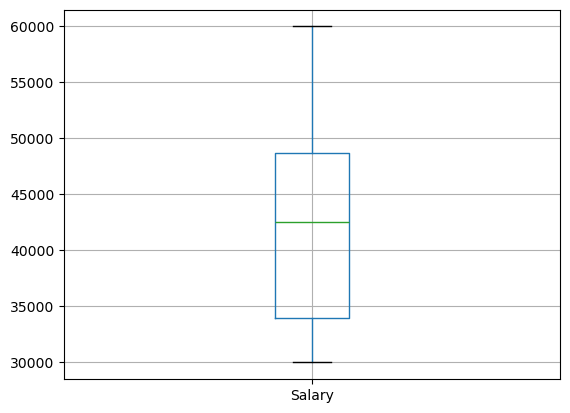

In [10]:
#Assumption 1 : there should be outliers in the data
#Check using boxplot
for i in data.columns:
    data.boxplot(column=i)
    plt.show()

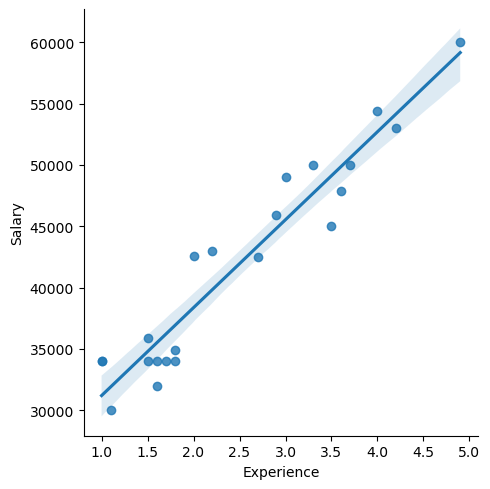

In [11]:
#Assumption 2 : Assumption of linwrarity every ind var should have a 
#Linear relationship with dep var 
sns.lmplot(data=data,x="Experience",y="Salary")
plt.show();

In [12]:
#STEP 4 data splitting
X=data.iloc[:,:-1]
Y=data.iloc[:,-1]

In [13]:
Y

0     34000
1     35900
2     34000
3     42579
4     33990
5     34000
6     43000
7     42500
8     30000
9     45900
10    34900
11    32000
12    34000
13    34000
14    49000
15    50000
16    49990
17    54390
18    53000
19    45000
20    47900
21    60000
Name: Salary, dtype: int64

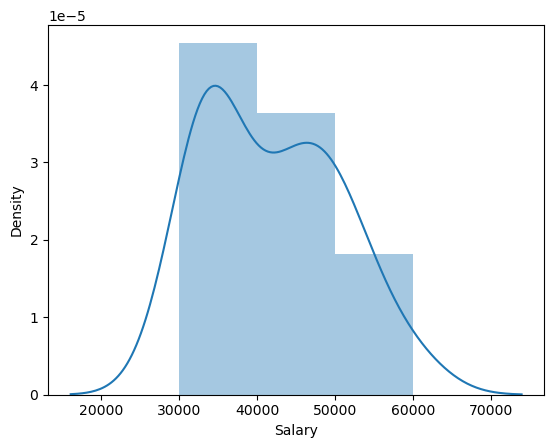

In [14]:
#Assumption 3 . Assumption of normality : The dependent variables should fpllow an appropriate normal distribution 
sns.distplot(Y)
plt.show()

In [15]:
# splitting the dataset into trainning and test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=1/3,random_state=10)

In [16]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(14, 1)
(8, 1)
(14,)
(8,)


In [17]:
#fitting the Simple Linear regression model to the training dataset
from sklearn.linear_model import LinearRegression 
#create a model object
lm=LinearRegression()
#train the model object
lm.fit(x_train,y_train) #input

#print intercept and coefficients
print(lm.intercept_)
print(lm.coef_)

24203.73547209682
[7242.66961227]


In [18]:
x1 = 1.5
ypred = 24203.73547209682 + (7242.66961227*x1)
ypred

35067.73989050182

In [19]:
y_pred=lm.predict(x_test)
x_pred=lm.predict(x_train)

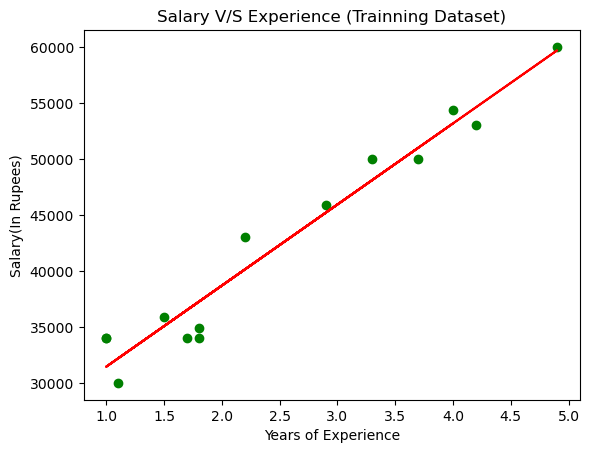

In [20]:
plt.scatter(x_train,y_train,color="green")
plt.plot(x_train,x_pred,color="red")
plt.title("Salary V/S Experience (Trainning Dataset)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary(In Rupees)")
plt.show()

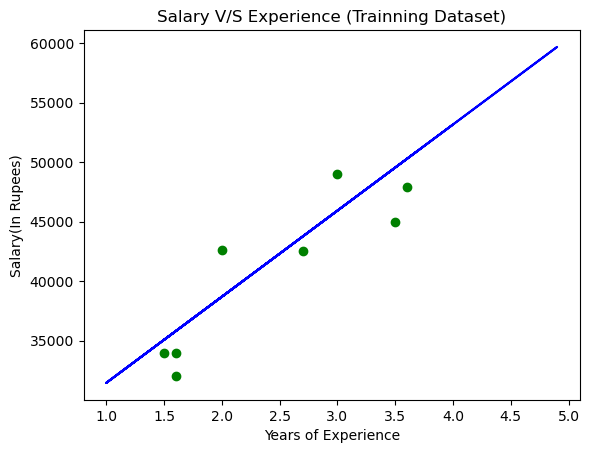

In [21]:
plt.scatter(x_test,y_test,color="green")
plt.plot(x_train,x_pred,color="blue")
plt.title("Salary V/S Experience (Trainning Dataset)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary(In Rupees)")
plt.show()

In [22]:
import pandas as pd
#Creating a Dataframe with x_test,y_test,and y_pred
results_df=pd.DataFrame({"Experience":x_test.squeeze(),"Actual Salary":y_test,"Predicted Salary":y_pred})
results_df.reset_index(drop="index")
results_df

,Experience,Actual Salary,Predicted Salary
14,3.0,49000,45931.744309
5,1.5,34000,35067.739891
2,1.6,34000,35792.006852
11,1.6,32000,35792.006852
7,2.7,42500,43758.943425
19,3.5,45000,49553.079115
3,2.0,42579,38689.074697
20,3.6,47900,50277.346076


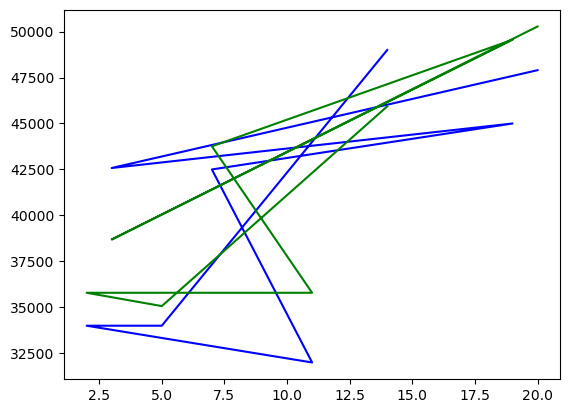

In [23]:
results_df["Actual Salary"].plot(color="blue")
results_df["Predicted Salary"].plot(color="green")
plt.show()

In [24]:
results_df["Residual"]=results_df["Actual Salary"]-results_df["Predicted Salary"]
results_df

,Experience,Actual Salary,Predicted Salary,Residual
14,3.0,49000,45931.744309,3068.255691
5,1.5,34000,35067.739891,-1067.739891
2,1.6,34000,35792.006852,-1792.006852
11,1.6,32000,35792.006852,-3792.006852
7,2.7,42500,43758.943425,-1258.943425
19,3.5,45000,49553.079115,-4553.079115
3,2.0,42579,38689.074697,3889.925303
20,3.6,47900,50277.346076,-2377.346076


In [25]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R-squared:",r2)

R-squared: 0.7710849073915436


In [26]:
#Test data --> unseeen data
test = pd.DataFrame({"Experience":[2,5,6,0,1,1.8,3]})
test

,Experience
0,2.0
1,5.0
2,6.0
3,0.0
4,1.0
5,1.8
6,3.0


In [27]:
y_new = lm.predict(test)
y_new

array([38689.07469663, 60417.08353344, 67659.75314571, 24203.7354721 ,
       31446.40508437, 37240.54077418, 45931.7443089 ])